In [1]:
# Stage 04 - data acquisition and ingestion

In [2]:
# --- run me first ---
from pathlib import Path
import os, sys

if Path.cwd().name == 'notebooks':
    os.chdir('..')  # project/notebooks -> project

ROOT = Path.cwd()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('working from:', ROOT.name)

working from: project


In [3]:
import os
import datetime as dt
import pathlib

from typing import Dict, List

import requests
import pandas as pd
from dotenv import load_dotenv

In [4]:
DATA_RAW = pathlib.Path("data/raw")
DATA_RAW.mkdir(parents=True, exist_ok=True)

load_dotenv()

ALPHA_KEY = os.getenv("ALPHAVANTAGE_API_KEY")

print("Loaded ALPHAVANTAGE_API_KEY?", bool(ALPHA_KEY))
DATA_RAW.mkdir(parents=True, exist_ok=True)
ALPHA_KEY = os.getenv("ALPHAVANTAGE_API_KEY")
bool(ALPHA_KEY)

Loaded ALPHAVANTAGE_API_KEY? False


False

In [5]:
def safe_stamp():
    return dt.datetime.now().strftime("%Y%m%d-%H%M%S")
    dt.datetime.now()
    strftime("%Y%m%d-%H%M%S")

In [6]:
def safe_filename(prefix: str, meta: Dict[str, str]) -> str:
    mid = "_".join(
        [f"{k}-{str(v).replace(' ', '-')[:20]}" for k, v in meta.items()]
    )
    return f"{prefix}_{mid}_{safe_stamp()}.csv"

In [7]:
def validate_df(
    df: pd.DataFrame,
    required_cols: List[str],
    dtypes_map: Dict[str, str]
) -> Dict[str, str]:

    msgs = {}

    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        msgs['missing_cols'] = f"Missing columns: {missing}"

    for col, dtype in dtypes_map.items():
        if col in df.columns:
            try:
                if dtype == 'datetime64[ns]':
                    pd.to_datetime(df[col])
                elif dtype == 'float':
                    pd.to_numeric(df[col])
            except Exception as e:
                msgs[f'dtype_{col}'] = (
                    f"Failed to coerce {col} to {dtype}: {e}"
                )

    na_counts = df.isna().sum().sum()
    msgs['na_total'] = f"Total NA values: {na_counts}"

    return msgs

In [8]:
SYMBOL = "SPY"
use_alpha = bool(ALPHA_KEY)

print("Using Alpha Vantage:", use_alpha)
print("Using Alpha Vantage:", use_alpha)

if use_alpha:
    url = "https://www.alphavantage.co/query"

    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": SYMBOL,
        "outputsize": "compact",
        "apikey": ALPHA_KEY,
        "datatype": "json"
    }

    r = requests.get(
        url,
        params=params,
        timeout=30
    )

    r.raise_for_status()

    js = r.json()

    key = [
        k for k in js.keys()
        if "Time Series" in k
    ]

    if not key:
        print(
            "Alpha Vantage returned no series:",
            str(list(js.values())[0])[:150]
        )
        use_alpha = False

Using Alpha Vantage: False
Using Alpha Vantage: False


In [9]:
if use_alpha:

    series = js[key[0]]

    df_api = (
        pd.DataFrame(series)
        .T
        .rename_axis("date")
        .reset_index()
    )

    df_api = (
        df_api[["date", "4. close"]]
        .rename(columns={"4. close": "close"})
    )

    df_api["date"] = pd.to_datetime(
        df_api["date"]
    )

    df_api["close"] = pd.to_numeric(
        df_api["close"]
    )

In [10]:
if not use_alpha:

    import yfinance as yf

    df_api = (
        yf.download(
            SYMBOL,
            period="10y",
            interval="1d",
            auto_adjust=False,
            multi_level_index=False
        )
        .reset_index()[["Date", "Close"]]
    )

    df_api.columns = ["date", "close"]

[*********************100%***********************]  1 of 1 completed


In [11]:
df_api = (
    df_api
    .sort_values("date")
    .reset_index(drop=True)
)

In [12]:
msgs = validate_df(
    df_api,
    required_cols=["date", "close"],
    dtypes_map={
        "date": "datetime64[ns]",
        "close": "float"
    }
)

print(msgs)

{'na_total': 'Total NA values: 0'}


In [13]:
fname = safe_filename(
    prefix="api",
    meta={
        "source": "alpha" if use_alpha else "yfinance",
        "symbol": SYMBOL
    }
)

out_path = DATA_RAW / fname

df_api.to_csv(
    out_path,
    index=False
)

print("Saved:", out_path)

Saved: data\raw\api_source-yfinance_symbol-SPY_20260825-173155.csv


In [14]:
# Stage 05 — Data Storage

In [15]:
import os
import pathlib
import pandas as pd
from dotenv import load_dotenv

In [16]:
load_dotenv()

RAW_DIR = pathlib.Path(
    os.getenv("DATA_DIR_RAW", "data/raw")
)

PROC_DIR = pathlib.Path(
    os.getenv("DATA_DIR_PROCESSED", "data/processed")
)

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_DIR:", RAW_DIR.resolve())
print("PROC_DIR:", PROC_DIR.resolve())

RAW_DIR: C:\Users\PC\bootcamp_chen_he\project\data\raw
PROC_DIR: C:\Users\PC\bootcamp_chen_he\project\data\processed


In [17]:
spy_files = sorted(
    RAW_DIR.glob("*SPY*.csv")
)

print("SPY raw files found:", len(spy_files))
latest_spy_path = spy_files[-1]

print("Loading:", latest_spy_path)

SPY raw files found: 2
Loading: data\raw\api_source-yfinance_symbol-SPY_20260825-173155.csv


In [18]:
spy_raw = pd.read_csv(
    latest_spy_path,
    parse_dates=["date"]
)

In [19]:
def validate_spy_storage(df):
    checks = {
        "not_empty": not df.empty,
        "date_present": "date" in df.columns,
        "close_present": "close" in df.columns,
    }

    if "date" in df.columns:
        checks["date_is_datetime"] = (
            pd.api.types.is_datetime64_any_dtype(df["date"])
        )

    if "close" in df.columns:
        checks["close_is_numeric"] = (
            pd.api.types.is_numeric_dtype(df["close"])
        )

    return checks

In [20]:
storage_checks = validate_spy_storage(spy_raw)

print(storage_checks)

{'not_empty': True, 'date_present': True, 'close_present': True, 'date_is_datetime': True, 'close_is_numeric': True}


In [21]:
display(spy_raw.head())

print("Shape:", spy_raw.shape)

print(
    "Date range:",
    spy_raw["date"].min(),
    "to",
    spy_raw["date"].max()
)

,date,close
0,2016-08-26,217.289993
1,2016-08-29,218.360001
2,2016-08-30,218.000000
3,2016-08-31,217.380005
4,2016-09-01,217.389999


Shape: (2512, 2)
Date range: 2016-08-26 00:00:00 to 2026-08-25 00:00:00


In [22]:
# Stage 06 — Data Preprocessing

In [23]:
spy = spy_raw.copy()
spy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2512 non-null   datetime64[ns]
 1   close   2512 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.4 KB


In [24]:
spy.head()

,date,close
0,2016-08-26,217.289993
1,2016-08-29,218.360001
2,2016-08-30,218.000000
3,2016-08-31,217.380005
4,2016-09-01,217.389999


In [25]:
spy.isna().sum()

date     0
close    0
dtype: int64

In [26]:
spy.duplicated().sum()

np.int64(0)

In [27]:
spy["date"].duplicated().sum()

np.int64(0)

In [28]:
from src.cleaning import clean_spy_data
spy_clean = clean_spy_data(spy_raw)
print("Raw shape:", spy_raw.shape)
print("Clean shape:", spy_clean.shape)

Raw shape: (2512, 2)
Clean shape: (2512, 2)


In [29]:
print(
    "Missing values:"
)
print(spy_clean.isna().sum())

Missing values:
date     0
close    0
dtype: int64


In [30]:
print(
    "Duplicate dates:",
    spy_clean["date"].duplicated().sum()
)

Duplicate dates: 0


In [31]:
print(
    "Non-positive close prices:",
    (spy_clean["close"] <= 0).sum()
)

Non-positive close prices: 0


In [32]:
spy_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2512 non-null   datetime64[ns]
 1   close   2512 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.4 KB


In [33]:
spy_clean["date"].is_monotonic_increasing

True

In [34]:
processed_path = PROC_DIR / "spy_clean.csv"

spy_clean.to_csv(
    processed_path,
    index=False
)

print(
    "Saved cleaned data to:",
    processed_path
)

Saved cleaned data to: data\processed\spy_clean.csv


In [35]:
# Stage 07 — Outlier Analysis

In [36]:
spy_outliers = spy_clean.copy()

spy_outliers["daily_return"] = (
    spy_outliers["close"].pct_change()
)

spy_outliers.head()

,date,close,daily_return
0,2016-08-26,217.289993,NaN
1,2016-08-29,218.360001,0.004924
2,2016-08-30,218.000000,-0.001649
3,2016-08-31,217.380005,-0.002844
4,2016-09-01,217.389999,0.000046


In [37]:
from src.outliers import detect_outliers_iqr

In [38]:
spy_outliers["outlier_iqr"] = (
    detect_outliers_iqr(
        spy_outliers["daily_return"],
        k=1.5
    )
)
spy_outliers[
    spy_outliers["outlier_iqr"]
].head()

,date,close,daily_return,outlier_iqr
9,2016-09-09,213.279999,-0.023935,True
50,2016-11-07,213.149994,0.022057,True
361,2018-02-02,275.450012,-0.021770,True
362,2018-02-05,263.929993,-0.041823,True
365,2018-02-08,257.630005,-0.037509,True


In [39]:
spy_outliers["outlier_iqr"].value_counts()

outlier_iqr
False    2347
True      165
Name: count, dtype: int64

In [40]:
returns_all = spy_outliers[
    "daily_return"
].dropna()

returns_filtered = spy_outliers.loc[
    ~spy_outliers["outlier_iqr"],
    "daily_return"
].dropna()

sensitivity = pd.DataFrame({
    "all_data": [
        returns_all.mean(),
        returns_all.std(),
        returns_all.min(),
        returns_all.max()
    ],

    "without_iqr_outliers": [
        returns_filtered.mean(),
        returns_filtered.std(),
        returns_filtered.min(),
        returns_filtered.max()
    ]
},
index=[
    "mean_return",
    "std_return",
    "min_return",
    "max_return"
])

sensitivity

,all_data,without_iqr_outliers
mean_return,0.000567,0.001043
std_return,0.011359,0.007337
min_return,-0.109424,-0.018158
max_return,0.105019,0.019981


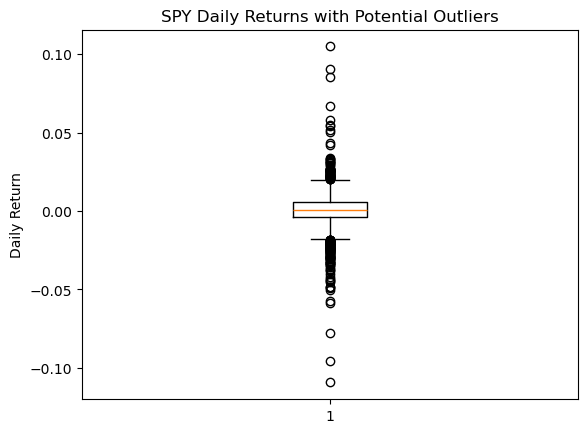

In [41]:
import matplotlib.pyplot as plt

plt.figure()

plt.boxplot(
    returns_all,
    vert=True
)

plt.title(
    "SPY Daily Returns with Potential Outliers"
)

plt.ylabel(
    "Daily Return"
)

plt.show()

In [42]:
outlier_path = (
    PROC_DIR /
    "spy_with_outlier_flags.csv"
)

spy_outliers.to_csv(
    outlier_path,
    index=False
)

print(
    "Saved:",
    outlier_path
)

Saved: data\processed\spy_with_outlier_flags.csv
